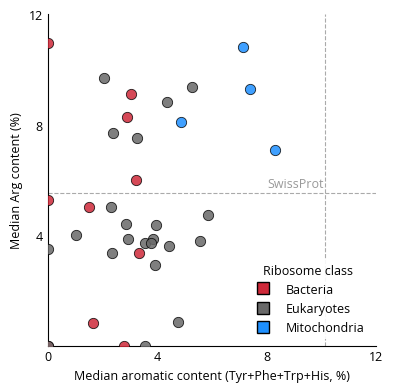

In [1]:
import os
import json
import re
from collections import defaultdict

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from adjustText import adjust_text

matplotlib.rcParams["font.size"] = 9
matplotlib.rcParams["font.family"] = "Open Sans"

BASE_DIR = ".."
RESULTS_AA_CONTENT_DIR = f"{BASE_DIR}/RESULTS_AA_CONTENT"
PLOT_DIR = f"{BASE_DIR}/PLOTS"

EXCLUDED_CLASSES = {"archaea", "chloroplasts"}
DOMAIN_COLORS = {
    "bacteria":     "#CE2939",
    "eukaryotes":   "#696969",
    "mitochondria": "#1E90FF",
}
ANNOTATE_IDS = [
    # "7QI4",
    # "6XYW",
    # "6YWY",
    # "6YDP"
]

MARKER_SIZE = 55
XLIM = (0, 12)
YLIM = (0, 12)
SWISSPROT_AROMATIC = 10.13
SWISSPROT_ARG = 5.53


def load_aa_segments(pdb_id):
    aa_dir = os.path.join(RESULTS_AA_CONTENT_DIR, pdb_id)
    if not os.path.exists(aa_dir):
        return None

    segments = defaultdict(dict)
    for fname in os.listdir(aa_dir):
        match = re.match(r"^(.+)_(\d+)_(.+)\.npy$", fname)
        if not match:
            continue
        chain_id, fragment_id, analysis_name = match.group(1), match.group(2), match.group(3)
        if analysis_name not in ("aromatic_content", "r_content"):
            continue
        value = float(np.load(os.path.join(aa_dir, fname)))
        segments[(chain_id, fragment_id)][analysis_name] = value

    complete = {
        k: v for k, v in segments.items()
        if "aromatic_content" in v and "r_content" in v
    }
    return complete if complete else None


with open(os.path.join(BASE_DIR, "ribosome_info.json")) as f:
    ribosome_info = json.load(f)

per_ribosome = []
for entry in ribosome_info:
    pdb_id = entry["pdb_id"].upper()
    ribosome_class = entry["ribosome_class"]
    if ribosome_class in EXCLUDED_CLASSES:
        continue
    segments = load_aa_segments(pdb_id)
    if segments is None:
        continue

    aromatics = [v["aromatic_content"] for v in segments.values()]
    args = [v["r_content"] for v in segments.values()]

    per_ribosome.append({
        "pdb_id": pdb_id,
        "organism": entry["organism"],
        "median_aromatic": float(np.median(aromatics)) * 100,
        "median_arg": float(np.median(args)) * 100,
        "domain": ribosome_class,
        "color": DOMAIN_COLORS[ribosome_class],
    })

fig, ax = plt.subplots(figsize=(4, 4))

texts = []
for r in per_ribosome:
    ax.scatter(
        r["median_aromatic"],
        r["median_arg"],
        color=r["color"],
        s=MARKER_SIZE,
        alpha=0.85,
        linewidths=0.6,
        edgecolors="black",
        zorder=3,
    )
    if r["pdb_id"] in ANNOTATE_IDS:
        texts.append(ax.text(
            r["median_aromatic"], r["median_arg"],
            f"{r['pdb_id']}: $\\mathit{{{r['organism']}}}$",
            color="#333333",
            zorder=4,
        ))

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="#aaaaaa", lw=0.6),
    expand=(2, 1.5),
)
ax.axvline(
    SWISSPROT_AROMATIC,
    color="#aaaaaa", linewidth=0.8, linestyle="--", zorder=1,
)
ax.axhline(
    SWISSPROT_ARG,
    color="#aaaaaa", linewidth=0.8, linestyle="--", zorder=1,
)
ax.text(
    XLIM[1] * 0.84, SWISSPROT_ARG + 0.09,
    "SwissProt", color="#999999", va="bottom", ha="right",
)

ax.set_xlim(XLIM)
ax.set_ylim(YLIM)
ax.set_xticks([0, 4, 8, 12])
ax.set_yticks([4, 8, 12])
ax.set_xlabel("Median aromatic content (Tyr+Phe+Trp+His, %)")
ax.set_ylabel("Median Arg content (%)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_axisbelow(True)
ax.tick_params(length=0)

domain_handles = [
    mlines.Line2D(
        [], [],
        marker="s", color="none",
        markerfacecolor=DOMAIN_COLORS[d],
        markersize=8,
        label=d.capitalize(),
    )
    for d in DOMAIN_COLORS
]
ax.legend(
    handles=domain_handles,
    title="Ribosome class",
    loc="lower right",
    framealpha=0.9,
    edgecolor="none",
)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/llps_scatter.png", dpi=300, bbox_inches="tight")